# NASA IMS Bearing Dataset — Isolation Forest Anomaly Detection

**Project:** Industrial Predictive Maintenance — Anomaly Detection
**Notebook:** `03_IMS_Isolation_Forest.ipynb`
**Depends on:** `02_IMS_Feature_Engineering.ipynb` output (`data/processed/ims_features.csv`). This notebook does **not** modify or regenerate Notebooks 01/02, and does not re-read any raw IMS files.


## 1. Introduction & Objective

## 2. Imports

Standard scientific-Python stack plus scikit-learn for the model and preprocessing, `joblib` for saving the fitted model/scaler, and `json`/`time` for the summary and diagnostics. Seaborn is **not** used — Notebooks 01/02 didn't introduce it, and matplotlib is sufficient here, so we avoid adding a new dependency for no real benefit.


In [10]:
import json
import time
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

import joblib

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (11, 4)
plt.rcParams["axes.grid"] = True

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 3. Project Paths

Paths are derived from the same `IMS_ROOT` used in Notebooks 01/02 (`data/raw/ims`), so this notebook stays consistent with the existing project layout without hard-coding a separate root. Output directories are created if they don't already exist; nothing here overwrites Notebook 01/02 inputs or outputs.


In [11]:
# Same raw-data root as Notebooks 01/02.
IMS_ROOT = Path(r"C:\chadha Summer Internship\2nd\Predictive Maintenance\data\raw\ims")

# IMS_ROOT = <PROJECT_ROOT>/data/raw/ims, so PROJECT_ROOT is three levels up.
PROJECT_ROOT = IMS_ROOT.parents[2]

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed" /"ims"                       # Notebook 02 output lives here
FEATURES_PATH = PROCESSED_DIR / "ims_features.csv"           # exact file written by Notebook 02

RESULTS_DIR = PROJECT_ROOT / "results" / "IMS" / "isolation_forest"
MODELS_DIR = PROJECT_ROOT / "models" / "IMS"

for d in [RESULTS_DIR, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT   : {PROJECT_ROOT}")
print(f"FEATURES_PATH  : {FEATURES_PATH}  (exists: {FEATURES_PATH.exists()})")
print(f"RESULTS_DIR    : {RESULTS_DIR}")
print(f"MODELS_DIR     : {MODELS_DIR}")


PROJECT_ROOT   : C:\chadha Summer Internship\2nd\Predictive Maintenance
FEATURES_PATH  : C:\chadha Summer Internship\2nd\Predictive Maintenance\data\processed\ims\ims_features.csv  (exists: True)
RESULTS_DIR    : C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest
MODELS_DIR     : C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS


## 4. Configuration

Every methodological choice that affects the model is centralized here, rather than scattered through the notebook. `BASELINE_FRACTION` controls the chronological split described in Section 1; `THRESHOLD_PERCENTILE` controls how the anomaly threshold is derived from the baseline in Section 13; the Isolation Forest hyperparameters are the standard scikit-learn defaults for the ensemble size/sampling, which are a reasonable, well-documented starting point for this kind of tabular anomaly-detection task and are revisited in the diagnostics/conclusion if the results suggest they should be.


In [12]:
CONFIG = {
    "RANDOM_SEED": RANDOM_SEED,

    # Chronological split: fraction of each run's *unique timestamps* used as the
    # healthy baseline for training the scaler, the model, and the threshold.
    "BASELINE_FRACTION": 0.20,

    # Fraction of each run (from the end) treated as the "late/degradation" period
    # for the baseline-vs-late comparison in Section 13. Independent of BASELINE_FRACTION.
    "LATE_FRACTION": 0.20,

    # Isolation Forest hyperparameters.
    "CONTAMINATION": "auto",
    "N_ESTIMATORS": 300,
    "MAX_SAMPLES": "auto",
    "MAX_FEATURES": 1.0,
    "N_JOBS": -1,

    # Percentile of the BASELINE anomaly-score distribution used as the anomaly
    # threshold (e.g. 99 -> threshold flags ~1% of the healthy baseline itself,
    # a deliberate small false-positive allowance rather than a hard "zero" cutoff).
    "THRESHOLD_PERCENTILE": 99,

    # Window (in snapshots) for the rolling-mean anomaly-score trend line.
    "ROLLING_WINDOW": 10,

    "RUNS": ["1st_test", "2nd_test", "3rd_test"],
}

CONFIG


{'RANDOM_SEED': 42,
 'BASELINE_FRACTION': 0.2,
 'LATE_FRACTION': 0.2,
 'CONTAMINATION': 'auto',
 'N_ESTIMATORS': 300,
 'MAX_SAMPLES': 'auto',
 'MAX_FEATURES': 1.0,
 'N_JOBS': -1,
 'THRESHOLD_PERCENTILE': 99,
 'ROLLING_WINDOW': 10,
 'RUNS': ['1st_test', '2nd_test', '3rd_test']}

## 5. Load Engineered Features

We load exactly the feature table produced by Notebook 02 — no raw IMS files are re-read here. `load_features()` performs the structural checks requested: the file exists and is non-empty, the expected identifier columns (`test_set`, `timestamp`, `channel`) are present, `test_set` values match the three expected runs, and `timestamp` is parsed to an actual datetime type.


In [13]:
def load_features(path, expected_runs):
    """Load Notebook 02's feature table and perform basic structural checks."""
    if not path.exists():
        raise FileNotFoundError(
            f"Feature file not found at {path}. Run 02_IMS_Feature_Engineering.ipynb first."
        )

    df = pd.read_csv(path)

    if df.empty:
        raise ValueError(f"Feature file at {path} is empty.")

    required_id_cols = {"test_set", "timestamp", "channel"}
    missing_id_cols = required_id_cols - set(df.columns)
    if missing_id_cols:
        raise ValueError(f"Missing expected identifier column(s): {missing_id_cols}")

    df["timestamp"] = pd.to_datetime(df["timestamp"])

    unexpected_runs = set(df["test_set"].unique()) - set(expected_runs)
    if unexpected_runs:
        warnings.warn(f"Unexpected test_set values found (not in CONFIG['RUNS']): {unexpected_runs}")

    return df


features_df = load_features(FEATURES_PATH, CONFIG["RUNS"])
print(f"Loaded feature table: {features_df.shape[0]} rows x {features_df.shape[1]} columns")
features_df.head()


Loaded feature table: 38976 rows x 14 columns


,test_set,timestamp,channel,mean,std,rms,peak_abs_amplitude,peak_to_peak,skewness,kurtosis,crest_factor,dominant_frequency_hz,spectral_energy,spectral_centroid_hz
0,1st_test,2003-10-22 12:06:24,channel_1,-0.094593,0.081122,0.124614,0.720,1.108,-0.029993,1.069163,5.777850,986.328125,0.005805,991.846126
1,1st_test,2003-10-22 12:09:13,channel_1,-0.094903,0.079515,0.123811,0.654,1.042,-0.070075,1.161552,5.282236,986.328125,0.005605,988.684214
2,1st_test,2003-10-22 12:14:13,channel_1,-0.096187,0.080217,0.125246,0.623,0.940,-0.041646,0.986286,4.974196,986.328125,0.005708,988.964900
3,1st_test,2003-10-22 12:19:13,channel_1,-0.095613,0.080825,0.125197,0.598,1.055,0.005162,1.034294,4.776455,986.328125,0.005722,1002.654202
4,1st_test,2003-10-22 12:24:13,channel_1,-0.095133,0.082034,0.125618,0.623,1.011,-0.060196,1.110164,4.959475,986.328125,0.005764,985.533206


### Data-quality checks

Beyond the structural checks above, we explicitly check for duplicate observations, non-numeric feature columns, and NaN/Inf values before doing anything else with the data. As in Notebook 02, nothing is silently dropped here — issues are counted and reported, and (where they affect modeling) are handled deliberately later in Section 9.


In [14]:
candidate_feature_cols = [c for c in features_df.columns if c not in ("test_set", "timestamp", "channel")]

duplicate_rows = features_df.duplicated(subset=["test_set", "timestamp", "channel"]).sum()
non_numeric_cols = [c for c in candidate_feature_cols if not pd.api.types.is_numeric_dtype(features_df[c])]
nan_counts = features_df[candidate_feature_cols].isnull().sum()
inf_counts = np.isinf(features_df[candidate_feature_cols].select_dtypes(include=[np.number])).sum()

print(f"Duplicate (test_set, timestamp, channel) rows : {duplicate_rows}")
print(f"Non-numeric candidate feature columns         : {non_numeric_cols}")
print(f"\nNaN counts per column:\n{nan_counts[nan_counts > 0]}")
print(f"\nInf counts per column:\n{inf_counts[inf_counts > 0]}")


Duplicate (test_set, timestamp, channel) rows : 0
Non-numeric candidate feature columns         : []

NaN counts per column:
Series([], dtype: int64)

Inf counts per column:
Series([], dtype: int64)


In [15]:
# Summary of the loaded dataset, as requested.
print(f"Number of rows    : {len(features_df)}")
print(f"Number of runs     : {features_df['test_set'].nunique()}")
print(f"Number of candidate feature columns: {len(candidate_feature_cols)}")

print("\nRows per run:")
print(features_df.groupby("test_set").size())

print("\nDate/time range per run:")
print(features_df.groupby("test_set")["timestamp"].agg(["min", "max"]))


Number of rows    : 38976
Number of runs     : 3
Number of candidate feature columns: 11

Rows per run:
test_set
1st_test    17248
2nd_test     3936
3rd_test    17792
dtype: int64

Date/time range per run:
                         min                 max
test_set                                        
1st_test 2003-10-22 12:06:24 2003-11-25 23:39:56
2nd_test 2004-02-12 10:32:39 2004-02-19 06:22:39
3rd_test 2004-03-04 09:27:46 2004-04-04 19:01:57


## 6. Identify Feature Columns

`FEATURE_COLUMNS` is fixed once here and used unchanged for every run and every later step (scaling, training, scoring). It explicitly excludes the identifier columns (`test_set`, `timestamp`, `channel`) and, defensively, any non-numeric column — none of these are model inputs, since none of them describe the actual vibration signal, and using timestamp or run identity as a feature would let the model "cheat" by learning time/run identity rather than signal behavior.


In [16]:
def identify_feature_columns(df, id_columns=("test_set", "timestamp", "channel")):
    """Return the numeric, non-identifier columns of df, in a fixed order.

    Explicitly excludes timestamps, run/channel identifiers, and any non-numeric
    column, so nothing that isn't a genuine signal-derived feature can end up
    being used as a model input.
    """
    candidates = [c for c in df.columns if c not in id_columns]
    numeric_cols = [c for c in candidates if pd.api.types.is_numeric_dtype(df[c])]
    dropped = [c for c in candidates if c not in numeric_cols]
    if dropped:
        print(f"Excluding non-numeric candidate column(s) from FEATURE_COLUMNS: {dropped}")
    return numeric_cols


FEATURE_COLUMNS = identify_feature_columns(features_df)
print(f"Number of model features: {len(FEATURE_COLUMNS)}")
print("FEATURE_COLUMNS (fixed order):")
for c in FEATURE_COLUMNS:
    print(f"  - {c}")


Number of model features: 11
FEATURE_COLUMNS (fixed order):
  - mean
  - std
  - rms
  - peak_abs_amplitude
  - peak_to_peak
  - skewness
  - kurtosis
  - crest_factor
  - dominant_frequency_hz
  - spectral_energy
  - spectral_centroid_hz


## 7. Chronological Organization & Baseline Selection

For each run, observations are sorted chronologically and the first `BASELINE_FRACTION` of the run's **unique timestamps** define the healthy baseline. Using unique timestamps (rather than raw row count) as the split unit means the baseline cutoff falls at the same point in time for every channel of a run, rather than accidentally including more of some channels than others.


In [17]:
def split_baseline(df_run, baseline_fraction):
    """Sort a single run chronologically and extract its early baseline period.

    Returns (full_sorted_df, baseline_df, baseline_end_timestamp). The baseline
    is defined by the first `baseline_fraction` of *unique timestamps* in the
    run, so every channel is represented consistently up to the same cutoff time.
    """
    df_sorted = df_run.sort_values(["timestamp", "channel"]).reset_index(drop=True)

    unique_timestamps = np.sort(df_sorted["timestamp"].unique())
    n_baseline_timestamps = max(1, int(len(unique_timestamps) * baseline_fraction))
    baseline_end_time = pd.Timestamp(unique_timestamps[n_baseline_timestamps - 1])

    baseline_mask = df_sorted["timestamp"] <= baseline_end_time
    baseline_df = df_sorted[baseline_mask].copy()

    return df_sorted, baseline_df, baseline_end_time


baseline_summary_rows = []
run_data = {}  # run -> {"full": ..., "baseline_raw": ..., "baseline_end_time": ...}

for run in CONFIG["RUNS"]:
    df_run = features_df[features_df["test_set"] == run]
    if df_run.empty:
        print(f"WARNING: no rows found for run '{run}' - skipping.")
        continue

    full_sorted, baseline_raw, baseline_end_time = split_baseline(df_run, CONFIG["BASELINE_FRACTION"])
    run_data[run] = {"full": full_sorted, "baseline_raw": baseline_raw, "baseline_end_time": baseline_end_time}

    baseline_summary_rows.append({
        "run": run,
        "total_observations": len(full_sorted),
        "baseline_observations": len(baseline_raw),
        "baseline_fraction": len(baseline_raw) / len(full_sorted),
        "baseline_end_time": baseline_end_time,
    })

baseline_summary = pd.DataFrame(baseline_summary_rows)
baseline_summary


,run,total_observations,baseline_observations,baseline_fraction,baseline_end_time
0,1st_test,17248,3448,0.199907,2003-11-01 10:21:44
1,2nd_test,3936,784,0.199187,2004-02-13 19:02:39
2,3rd_test,17792,3556,0.199865,2004-03-10 13:22:46


## 8. Handling Missing Values (Near-Flat Signals)

Notebook 01 flagged that some IMS runs contain near-flat, very-low-amplitude final snapshots. When Notebook 02 computed skewness/kurtosis on such a (near-)constant signal, those statistics are mathematically undefined and came out as `NaN` (this is expected — see Notebook 02, Section 8). `IsolationForest` and `StandardScaler` cannot accept `NaN` inputs, so these values need to be handled before modeling — but per the project's constraints, they must **not** be silently dropped.

**Approach:** any `NaN` (or stray `Inf`, treated the same way) in a feature column is filled with that **run's own baseline median** for that feature. This is a deliberate, minimal, documented choice:
- The baseline median is computed from *healthy* observations only, so this does not leak degradation information into the fill values.
- A flat/near-zero-variance signal is itself informative (very low RMS/std) even when a particular statistic like kurtosis is undefined — filling with a typical *healthy* value avoids inventing an extreme value that could bias the model, while every affected row is explicitly flagged (`had_missing_features`) so it can be inspected later rather than disappearing into the pipeline unnoticed (Section 15).


In [18]:
def handle_missing_values(full_df, baseline_df, feature_cols):
    """Fill NaN/Inf feature values using the run's own baseline median.

    Returns (full_df_filled, baseline_df_filled, fill_values, had_missing_mask).
    Every row that had at least one missing/infinite feature value is flagged in
    the returned `had_missing_features` column - nothing is dropped.
    """
    full_df = full_df.replace([np.inf, -np.inf], np.nan)
    baseline_df = baseline_df.replace([np.inf, -np.inf], np.nan)

    had_missing_mask = full_df[feature_cols].isnull().any(axis=1)

    fill_values = baseline_df[feature_cols].median()
    fill_values = fill_values.fillna(0.0)  # safety net if an entire baseline column were NaN

    full_df_filled = full_df.copy()
    full_df_filled[feature_cols] = full_df_filled[feature_cols].fillna(fill_values)
    full_df_filled["had_missing_features"] = had_missing_mask.values

    baseline_df_filled = baseline_df.copy()
    baseline_df_filled[feature_cols] = baseline_df_filled[feature_cols].fillna(fill_values)

    return full_df_filled, baseline_df_filled, fill_values


for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    full_filled, baseline_filled, fill_values = handle_missing_values(
        run_data[run]["full"], run_data[run]["baseline_raw"], FEATURE_COLUMNS
    )
    run_data[run]["full_filled"] = full_filled
    run_data[run]["baseline_filled"] = baseline_filled
    run_data[run]["fill_values"] = fill_values

    n_missing = int(full_filled["had_missing_features"].sum())
    print(f"{run}: {n_missing} row(s) had at least one missing/infinite feature value "
          f"(filled with baseline median, flagged in 'had_missing_features')")


1st_test: 0 row(s) had at least one missing/infinite feature value (filled with baseline median, flagged in 'had_missing_features')
2nd_test: 0 row(s) had at least one missing/infinite feature value (filled with baseline median, flagged in 'had_missing_features')
3rd_test: 0 row(s) had at least one missing/infinite feature value (filled with baseline median, flagged in 'had_missing_features')


## 9. Fit Preprocessing on Baseline Only

`IsolationForest` splits on individual features, so it is less sensitive to feature scale than distance-based methods — but our 11 features span very different numeric ranges (e.g. `spectral_energy` vs `skewness`), and mixing raw scales can still distort how the ensemble's random splits are distributed across features. We standardize features (zero mean, unit variance) with `StandardScaler`.

**Critically, the scaler is fit only on each run's healthy baseline**, never on the full run:

```text
Healthy baseline
      ↓
Scaler.fit()
      ↓
transform baseline
      ↓
transform complete timeline
```

If we fit the scaler on the entire run instead, the mean/variance used to standardize *every* observation — including the earliest, healthiest ones — would already be shifted by the degraded/failure-period values, since those tend to have much larger magnitude and variance. That would let information about the failure period leak into how "normal" data is represented, undermining the whole premise of using an early baseline as the reference for "normal".


In [19]:
def fit_preprocessor(baseline_df, feature_cols):
    """Fit a StandardScaler on baseline (healthy) observations only."""
    scaler = StandardScaler()
    scaler.fit(baseline_df[feature_cols].values)
    return scaler


for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scaler = fit_preprocessor(run_data[run]["baseline_filled"], FEATURE_COLUMNS)
    run_data[run]["scaler"] = scaler
    print(f"{run}: scaler fit on {len(run_data[run]['baseline_filled'])} baseline observations")


1st_test: scaler fit on 3448 baseline observations
2nd_test: scaler fit on 784 baseline observations
3rd_test: scaler fit on 3556 baseline observations


## 10. Train Isolation Forest on Baseline Only


In [20]:
def train_isolation_forest(X_baseline_scaled, config):
    """Fit one Isolation Forest on a run's scaled healthy baseline data."""
    model = IsolationForest(
        n_estimators=config["N_ESTIMATORS"],
        contamination=config["CONTAMINATION"],
        max_samples=config["MAX_SAMPLES"],
        max_features=config["MAX_FEATURES"],
        random_state=config["RANDOM_SEED"],
        n_jobs=config["N_JOBS"],
    )
    model.fit(X_baseline_scaled)
    return model


run_models = {}
training_times = {}

for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scaler = run_data[run]["scaler"]  # already fit per-run in Section 9 (Cell 20)
    X_baseline = run_data[run]["baseline_filled"][FEATURE_COLUMNS].values
    X_baseline_scaled = scaler.transform(X_baseline)

    start_time = time.time()
    model = train_isolation_forest(X_baseline_scaled, CONFIG)
    training_times[run] = time.time() - start_time

    run_data[run]["model"] = model

    print(f"{run}: trained on {X_baseline_scaled.shape[0]} baseline observations, "
          f"{X_baseline_scaled.shape[1]} features, "
          f"in {training_times[run]:.3f}s")

print("\n✓ Trained one Isolation Forest per run (3 independent models).")

1st_test: trained on 3448 baseline observations, 11 features, in 0.485s
2nd_test: trained on 784 baseline observations, 11 features, in 0.433s
3rd_test: trained on 3556 baseline observations, 11 features, in 0.417s

✓ Trained one Isolation Forest per run (3 independent models).


In [21]:
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    model_path = MODELS_DIR / f"{run}_isolation_forest.joblib"
    scaler_path = MODELS_DIR / f"{run}_scaler.joblib"

    joblib.dump(run_data[run]["model"], model_path)
    joblib.dump(run_data[run]["scaler"], scaler_path)

    run_data[run]["model_path"] = model_path
    run_data[run]["scaler_path"] = scaler_path

    print(f"{run}: model -> {model_path}")
    print(f"{run}: scaler -> {scaler_path}")

print("\n✓ Saved one Isolation Forest + one scaler per run (3 models, 3 scalers).")

1st_test: model -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\1st_test_isolation_forest.joblib
1st_test: scaler -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\1st_test_scaler.joblib
2nd_test: model -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\2nd_test_isolation_forest.joblib
2nd_test: scaler -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\2nd_test_scaler.joblib
3rd_test: model -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\3rd_test_isolation_forest.joblib
3rd_test: scaler -> C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS\3rd_test_scaler.joblib

✓ Saved one Isolation Forest + one scaler per run (3 models, 3 scalers).


## 11. Score Complete Chronological Runs

Each run's model scores **every** observation in that run's complete chronological timeline (not just the baseline). As noted in Section 10, scikit-learn's `decision_function` returns higher values for *more normal* points. We explicitly flip the sign so that, for the rest of this notebook:

> **`anomaly_score` — higher value = more anomalous.**

This is a deliberate transformation, not an assumption about scikit-learn's default direction.


In [22]:
def score_run(model, scaler, df, feature_cols):
    """Score every row of df with a fitted model/scaler.

    Returns a copy of df with two new columns:
      - anomaly_score: -decision_function(X)  =>  HIGHER = MORE ANOMALOUS.
      - model_predict: scikit-learn's own inlier(1)/outlier(-1) label, kept for reference only.
    """
    X = scaler.transform(df[feature_cols].values)
    raw_decision = model.decision_function(X)   # sklearn: higher = more normal
    anomaly_score = -raw_decision                # flipped: higher = more anomalous

    result = df.copy()
    result["anomaly_score"] = anomaly_score
    result["model_predict"] = model.predict(X)
    return result

scoring_times = {}
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    start = time.time()
    scored = score_run(
        run_data[run]["model"],
        run_data[run]["scaler"],
        run_data[run]["full_filled"],
        FEATURE_COLUMNS,
    )
    elapsed = time.time() - start

    run_data[run]["scored"] = scored
    scoring_times[run] = elapsed
    print(f"{run}: scored {len(scored)} observations in {elapsed:.3f}s "
          f"(anomaly_score range: [{scored['anomaly_score'].min():.4f}, {scored['anomaly_score'].max():.4f}])")


1st_test: scored 17248 observations in 0.530s (anomaly_score range: [-0.1070, 0.2370])
2nd_test: scored 3936 observations in 0.140s (anomaly_score range: [-0.1027, 0.2290])
3rd_test: scored 17792 observations in 0.577s (anomaly_score range: [-0.1135, 0.1811])


In [23]:
# Sanity check: 3 independent models/scalers, each scored on its own data
assert len(set(id(run_data[r]["model"]) for r in CONFIG["RUNS"])) == 3, \
    "Models are not independent — still sharing one global model."
assert len(set(id(run_data[r]["scaler"]) for r in CONFIG["RUNS"])) == 3, \
    "Scalers are not independent — still sharing one global scaler."
for r in CONFIG["RUNS"]:
    n_train = run_data[r]["model"].n_features_in_
    print(f"{r}: model trained on {run_data[r]['scaler'].n_samples_seen_} samples, "
          f"{n_train} features")
print("✓ Three independent Isolation Forest models confirmed.")

1st_test: model trained on 3448 samples, 11 features
2nd_test: model trained on 784 samples, 11 features
3rd_test: model trained on 3556 samples, 11 features
✓ Three independent Isolation Forest models confirmed.


## 12. Determine Anomaly Threshold from Baseline

The anomaly threshold for each run is set at the `THRESHOLD_PERCENTILE`-th percentile of **that run's own baseline anomaly scores only** — never using any information from the degradation/failure period, and never tuned to "look correct" against the known failure. With `THRESHOLD_PERCENTILE = 99`, the threshold is, by construction, expected to flag roughly the top 1% of the *healthy baseline itself* as anomalous — a deliberate small false-positive allowance, rather than an arbitrary or zero-tolerance cutoff.


In [24]:
def compute_threshold(baseline_scored, percentile):
    """Anomaly-score threshold at a given percentile of BASELINE scores only."""
    return float(np.percentile(baseline_scored["anomaly_score"].values, percentile))


for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    baseline_end_time = run_data[run]["baseline_end_time"]
    baseline_scored = scored[scored["timestamp"] <= baseline_end_time]

    threshold = compute_threshold(baseline_scored, CONFIG["THRESHOLD_PERCENTILE"])
    run_data[run]["threshold"] = threshold
    run_data[run]["baseline_scored"] = baseline_scored

    print(f"{run}: threshold = {threshold:.4f}  "
          f"(from {len(baseline_scored)} baseline observations, "
          f"{CONFIG['THRESHOLD_PERCENTILE']}th percentile)")


1st_test: threshold = 0.0819  (from 3448 baseline observations, 99th percentile)
2nd_test: threshold = 0.1232  (from 784 baseline observations, 99th percentile)
3rd_test: threshold = 0.1028  (from 3556 baseline observations, 99th percentile)


## 13. Anomaly Classification

With a threshold defined per run, every scored observation is labeled `anomaly_flag = anomaly_score > threshold`. This is applied uniformly across the entire chronological timeline (baseline included, by design — the baseline should show close to the target false-positive rate, which is itself a useful sanity check).


In [25]:
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    threshold = run_data[run]["threshold"]
    scored["anomaly_flag"] = scored["anomaly_score"] > threshold
    run_data[run]["scored"] = scored

    # Refresh baseline_scored (captured in Section 12, before anomaly_flag existed)
    # so downstream sections see the flag column too.
    baseline_end_time = run_data[run]["baseline_end_time"]
    run_data[run]["baseline_scored"] = scored[scored["timestamp"] <= baseline_end_time]

    n_anom = int(scored["anomaly_flag"].sum())
    print(f"{run}: {n_anom} / {len(scored)} observations flagged as anomalous "
          f"({n_anom / len(scored) * 100:.2f}%)")


1st_test: 2035 / 17248 observations flagged as anomalous (11.80%)
2nd_test: 140 / 3936 observations flagged as anomalous (3.56%)
3rd_test: 52 / 17792 observations flagged as anomalous (0.29%)


## 14. Known Data-Quality Issue: Near-Flat Final Snapshots

Notebook 01 identified unusual near-flat, very-low-amplitude final snapshots in some IMS runs. Section 8 of this notebook flagged every observation whose raw features included a missing value (`had_missing_features`) — which, per Notebook 02, happens exactly when a signal is (near-)constant and its skewness/kurtosis become mathematically undefined. This section reports exactly which observations those are and how the model scored them, **without** assuming they represent genuine bearing failures.


In [26]:
flat_signal_report_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    flagged = scored[scored["had_missing_features"]]

    if flagged.empty:
        print(f"{run}: no near-flat / missing-feature observations detected.")
        continue

    print(f"\n{run}: {len(flagged)} near-flat / missing-feature observation(s) detected.")
    print(f"  Timestamp range of flagged observations: "
          f"{flagged['timestamp'].min()}  to  {flagged['timestamp'].max()}")
    print(f"  Channels affected: {sorted(flagged['channel'].unique())}")
    print(f"  Their anomaly_score range: "
          f"[{flagged['anomaly_score'].min():.4f}, {flagged['anomaly_score'].max():.4f}]  "
          f"(run threshold: {run_data[run]['threshold']:.4f})")
    print(f"  Fraction of these flagged as anomalous by our threshold: "
          f"{flagged['anomaly_flag'].mean() * 100:.1f}%")

    flat_signal_report_rows.append({
        "run": run,
        "n_near_flat_observations": len(flagged),
        "first_timestamp": flagged["timestamp"].min(),
        "last_timestamp": flagged["timestamp"].max(),
        "channels_affected": ", ".join(sorted(flagged["channel"].unique())),
        "mean_anomaly_score": flagged["anomaly_score"].mean(),
        "pct_flagged_anomalous": flagged["anomaly_flag"].mean() * 100,
    })

flat_signal_report = pd.DataFrame(flat_signal_report_rows)
flat_signal_report


1st_test: no near-flat / missing-feature observations detected.
2nd_test: no near-flat / missing-feature observations detected.
3rd_test: no near-flat / missing-feature observations detected.


""


**Interpretation.** A near-flat final snapshot could plausibly reflect a real end-of-experiment sensor event (e.g. the rig being powered down after failure), a data-acquisition artifact, or something else entirely — this dataset alone doesn't tell us which. The table above documents exactly where these observations sit in each run's timeline and how the model scored them, so a reader can judge for themselves; this notebook does not label them as confirmed failures or discard them from any of the analyses that follow.


## 15. Baseline vs. Degradation Period Comparison

To get a first quantitative sense of whether the anomaly score distribution actually shifts over a run, we compare the healthy baseline period against the **last `LATE_FRACTION` of the run** (a separate, independently configurable window from `BASELINE_FRACTION`). This is a descriptive comparison of two distributions, **not** a supervised classification evaluation — we have no ground-truth labels to score accuracy against.


In [27]:
def compute_anomaly_statistics(scores, flags):
    """Descriptive statistics for a set of anomaly scores (+ the derived flag rate)."""
    scores = np.asarray(scores, dtype=float)
    return {
        "count": int(len(scores)),
        "mean": float(np.mean(scores)),
        "median": float(np.median(scores)),
        "std": float(np.std(scores)),
        "p90": float(np.percentile(scores, 90)),
        "p99": float(np.percentile(scores, 99)),
        "anomaly_rate_pct": float(np.mean(flags) * 100),
    }


comparison_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    run_end = scored["timestamp"].max()
    run_start = scored["timestamp"].min()
    late_cutoff = run_end - (run_end - run_start) * CONFIG["LATE_FRACTION"]

    baseline_scored = scored[scored["timestamp"] <= run_data[run]["baseline_end_time"]]
    late_scored = scored[scored["timestamp"] >= late_cutoff]

    baseline_stats = compute_anomaly_statistics(baseline_scored["anomaly_score"], baseline_scored["anomaly_flag"])
    late_stats = compute_anomaly_statistics(late_scored["anomaly_score"], late_scored["anomaly_flag"])

    comparison_rows.append({"run": run, "period": "baseline", **baseline_stats})
    comparison_rows.append({"run": run, "period": f"late ({CONFIG['LATE_FRACTION']:.0%})", **late_stats})

baseline_vs_late = pd.DataFrame(comparison_rows)
baseline_vs_late


,run,period,count,mean,median,std,p90,p99,anomaly_rate_pct
0,1st_test,baseline,3448,-0.038236,-0.046220,0.039811,0.015305,0.081905,1.015081
1,1st_test,late (20%),5768,0.028422,-0.007276,0.095642,0.177929,0.210805,31.553398
2,2nd_test,baseline,784,-0.042754,-0.054102,0.046725,0.030701,0.123229,1.020408
3,2nd_test,late (20%),788,0.064275,0.065348,0.057068,0.136637,0.206027,14.340102
4,3rd_test,baseline,3556,-0.046161,-0.057476,0.044248,0.014914,0.102849,1.012373
5,3rd_test,late (20%),3596,-0.033232,-0.037370,0.038591,0.021220,0.060094,0.111235


## 16. Temporal Trend Analysis

We test whether anomaly scores show a **monotonic** trend over time using Spearman rank correlation between elapsed time and anomaly score. Spearman is used rather than Pearson because we only care about monotonic (rank-order) association, not a specifically linear one — degradation need not be linear. Per-timestamp scores are averaged across channels first, so a run with more channels (e.g. `1st_test`'s 8) doesn't get disproportionate weight in the correlation compared to `2nd_test`/`3rd_test`'s 4.

**Interpretation caveat:** a significant positive Spearman correlation means anomaly scores tend to rise as the run progresses — it does **not** by itself prove a specific physical degradation mechanism, only that the engineered features (as seen by this model) drift away from the healthy baseline over time.


In [28]:
def compute_trend_statistics(scored_run, rolling_window):
    """Spearman trend of the run-level (channel-averaged) anomaly score over time.

    Returns (trend_stats_dict, per_timestamp_agg_df). The aggregated dataframe also
    carries a rolling mean, used for the trend line in the main visualization.
    """
    agg = (scored_run.groupby("timestamp")["anomaly_score"]
           .mean().reset_index().sort_values("timestamp").reset_index(drop=True))
    time_numeric = (agg["timestamp"] - agg["timestamp"].min()).dt.total_seconds().values

    rho, p_value = spearmanr(time_numeric, agg["anomaly_score"].values)
    direction = "increasing" if rho > 0 else ("decreasing" if rho < 0 else "no monotonic trend")

    agg["rolling_mean_score"] = agg["anomaly_score"].rolling(window=rolling_window, min_periods=1).mean()

    return {"spearman_rho": rho, "p_value": p_value, "trend_direction": direction}, agg


trend_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    trend_stats, agg = compute_trend_statistics(run_data[run]["scored"], CONFIG["ROLLING_WINDOW"])
    run_data[run]["trend_agg"] = agg
    trend_rows.append({"run": run, **trend_stats})

trend_summary = pd.DataFrame(trend_rows)
trend_summary


,run,spearman_rho,p_value,trend_direction
0,1st_test,0.712034,0.000000e+00,increasing
1,2nd_test,0.787894,5.578434e-209,increasing
2,3rd_test,0.322680,2.614937e-108,increasing


## 17. Early-Warning / Time-to-Detection Analysis

For each run, we report when the *first* and *last* anomalous observation occurred, and what fraction of the run's total duration elapsed before that first detection. A channel is treated as flagging the run at a given timestamp if **any** channel at that timestamp exceeds the threshold — a single degrading bearing/channel is operationally meaningful even while other channels on the same run still look healthy. This is kept purely descriptive: the IMS dataset does not provide an exact physical failure time, so we do not invent one, and a small `fraction_before_first_anomaly` should be read as "the model started flagging deviations early in the run", not as a validated early-warning lead time.


In [29]:
def early_warning_analysis(scored_run, baseline_fraction=0.20):
    """Find the first anomaly after the baseline period."""
    scored_run = scored_run.sort_values("timestamp").reset_index(drop=True)
    baseline_end = int(len(scored_run) * baseline_fraction)
    # Only look for anomalies AFTER the baseline
    post_baseline = scored_run.iloc[baseline_end:]
    anomalous = post_baseline[post_baseline["anomaly_flag"]]
    run_start = scored_run["timestamp"].min()
    run_end = scored_run["timestamp"].max()
    total_duration_s = (run_end - run_start).total_seconds()
    if anomalous.empty or total_duration_s <= 0:
        return {
            "first_anomaly_timestamp": None,
            "last_anomaly_timestamp": None,
            "fraction_before_first_anomaly": None,
            "n_anomalous_timestamps": 0,
        }
    first_anomaly_time = anomalous["timestamp"].min()
    last_anomaly_time = anomalous["timestamp"].max()

    fraction_before = (
        (first_anomaly_time - run_start).total_seconds()
        / total_duration_s
    )
    return {
        "first_anomaly_timestamp": first_anomaly_time,
        "last_anomaly_timestamp": last_anomaly_time,
        "fraction_before_first_anomaly": fraction_before,
        "n_anomalous_timestamps": int(anomalous["timestamp"].nunique()),
    }


early_warning_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    result = early_warning_analysis(run_data[run]["scored"])
    run_data[run]["early_warning"] = result
    early_warning_rows.append({"run": run, **result})

early_warning_summary = pd.DataFrame(early_warning_rows)
early_warning_summary


,run,first_anomaly_timestamp,last_anomaly_timestamp,fraction_before_first_anomaly,n_anomalous_timestamps
0,1st_test,2003-11-01 12:21:44,2003-11-25 23:39:56,0.290318,843
1,2nd_test,2004-02-15 01:02:39,2004-02-19 06:22:39,0.381485,109
2,3rd_test,2004-03-10 17:12:46,2004-04-04 18:31:57,0.201375,16


In [30]:
def first_persistent_anomaly(scored_run,baseline_fraction=0.20,window=5,min_anomalies=3):
    scored_run = scored_run.sort_values("timestamp").reset_index(drop=True)
    # Aggregate channels at each timestamp
    timestamp_flags = (
        scored_run
        .groupby("timestamp")["anomaly_flag"]
        .agg(["sum", "count"])
        .reset_index()
    )
    # Number of anomalous channels at each timestamp
    timestamp_flags["anomaly_rate"] = (timestamp_flags["sum"] / timestamp_flags["count"])
    # Consider a timestamp anomalous only if at least `min_anomalies` channels are
    # anomalous simultaneously (default: 3) - NOT "at least one", which was a stale
    # comment left over from an earlier version of this function.
    timestamp_flags["timestamp_anomaly"] = (timestamp_flags["sum"] >= min_anomalies)
    # Ignore the first 20% baseline timestamps
    baseline_end = int(len(timestamp_flags) * baseline_fraction)
    post_baseline = timestamp_flags.iloc[baseline_end:].reset_index(drop=True)

    flags = post_baseline["timestamp_anomaly"].astype(int).to_numpy()

# Require `window` consecutive anomalous timestamps
    for i in range(len(flags) - window + 1):

        if flags[i:i + window].all():

            return post_baseline.iloc[i + window - 1]["timestamp"]

    return None

In [31]:
persistent_warning_rows = []

for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue

    first_persistent = first_persistent_anomaly(
        run_data[run]["scored"],
        baseline_fraction=0.20,
        window=3,
        min_anomalies=3
    )

    persistent_warning_rows.append({
        "run": run,
        "first_persistent_anomaly_timestamp": first_persistent
    })

persistent_warning_summary = pd.DataFrame(persistent_warning_rows)

persistent_warning_summary

,run,first_persistent_anomaly_timestamp
0,1st_test,2003-11-21 06:54:03
1,2nd_test,2004-02-19 04:32:39
2,3rd_test,NaT


In [32]:
# Channel-level anomaly rate around the first persistent anomaly

run = "1st_test"

scored = run_data[run]["scored"].sort_values("timestamp")

persistent_time = persistent_warning_summary.loc[
    persistent_warning_summary["run"] == run,
    "first_persistent_anomaly_timestamp"
].iloc[0]

inspection = scored[
    (scored["timestamp"] >= persistent_time - pd.Timedelta(minutes=30)) &
    (scored["timestamp"] <= persistent_time + pd.Timedelta(minutes=30))
]

channel_summary = (
    inspection
    .groupby("timestamp")["anomaly_flag"]
    .agg(
        anomalous_channels="sum",
        total_channels="count"
    )
    .reset_index()
)

channel_summary["anomaly_rate"] = (
    channel_summary["anomalous_channels"] /
    channel_summary["total_channels"]
)

channel_summary

,timestamp,anomalous_channels,total_channels,anomaly_rate
0,2003-11-21 06:24:03,2,8,0.250
1,2003-11-21 06:34:03,3,8,0.375
2,2003-11-21 06:44:03,3,8,0.375
3,2003-11-21 06:54:03,3,8,0.375
4,2003-11-21 07:04:03,2,8,0.250
5,2003-11-21 07:14:03,2,8,0.250
6,2003-11-21 07:24:03,2,8,0.250


In [33]:
persistent_warning_summary["run_end_timestamp"] = (
    persistent_warning_summary["run"]
    .map({
        run: run_data[run]["scored"]["timestamp"].max()
        for run in persistent_warning_summary["run"]
    })
)

# Guard: first_persistent_anomaly_timestamp is None whenever no persistent anomaly
# was found for a run (see Section 17). Coerce to datetime with errors="coerce" so
# those rows become NaT - and therefore NaN after the subtraction - instead of
# raising or silently producing a garbage value. No anomaly-detection logic changed.
_first_persistent_dt = pd.to_datetime(
    persistent_warning_summary["first_persistent_anomaly_timestamp"], errors="coerce"
)
persistent_warning_summary["warning_time_before_end_hours"] = (
    persistent_warning_summary["run_end_timestamp"] - _first_persistent_dt
).dt.total_seconds() / 3600

persistent_warning_summary

,run,first_persistent_anomaly_timestamp,run_end_timestamp,warning_time_before_end_hours
0,1st_test,2003-11-21 06:54:03,2003-11-25 23:39:56,112.764722
1,2nd_test,2004-02-19 04:32:39,2004-02-19 06:22:39,1.833333
2,3rd_test,NaT,2004-04-04 19:01:57,NaN


In [34]:
# Inspect all three runs around their first persistent anomaly (generalized from the
# earlier hardcoded run = "1st_test" version - same inspection logic, now per run).
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"].sort_values("timestamp").reset_index(drop=True)

    persistent_time = persistent_warning_summary.loc[
        persistent_warning_summary["run"] == run,
        "first_persistent_anomaly_timestamp"
    ].iloc[0]

    print(f"\n=== {run} ===")
    if pd.isna(persistent_time):
        print("No persistent anomaly found for this run (see Section 17) - skipping inspection window.")
        continue

    # Show observations around the persistent anomaly
    window = scored[
        (scored["timestamp"] >= persistent_time - pd.Timedelta(hours=2)) &
        (scored["timestamp"] <= persistent_time + pd.Timedelta(hours=2))
    ]

    print("First persistent anomaly:", persistent_time)
    print("Number of observations:", len(window))

    display(window[["timestamp", "anomaly_score", "anomaly_flag"]].head(20))


=== 1st_test ===
First persistent anomaly: 2003-11-21 06:54:03
Number of observations: 168


,timestamp,anomaly_score,anomaly_flag
13168,2003-11-21 04:54:03,0.183608,True
13169,2003-11-21 04:54:03,0.053295,False
13170,2003-11-21 04:54:03,-0.048868,False
13171,2003-11-21 04:54:03,0.176156,True
13172,2003-11-21 04:54:03,-0.057618,False
13173,2003-11-21 04:54:03,-0.057612,False
13174,2003-11-21 04:54:03,-0.031595,False
13175,2003-11-21 04:54:03,-0.042246,False
13176,2003-11-21 05:04:03,0.180122,True
13177,2003-11-21 05:04:03,0.080223,False



=== 2nd_test ===
First persistent anomaly: 2004-02-19 04:32:39
Number of observations: 96


,timestamp,anomaly_score,anomaly_flag
3840,2004-02-19 02:32:39,0.153038,True
3841,2004-02-19 02:32:39,0.093429,False
3842,2004-02-19 02:32:39,0.120402,False
3843,2004-02-19 02:32:39,0.050488,False
3844,2004-02-19 02:42:39,0.089377,False
3845,2004-02-19 02:42:39,0.076510,False
3846,2004-02-19 02:42:39,0.182436,True
3847,2004-02-19 02:42:39,0.068945,False
3848,2004-02-19 02:52:39,0.143467,True
3849,2004-02-19 02:52:39,0.075375,False



=== 3rd_test ===
No persistent anomaly found for this run (see Section 17) - skipping inspection window.


## 18. Anomaly Score Visualizations

For each run we plot every channel's anomaly score over time (light points, one color per channel), the run-level rolling mean (bold line) to show the overall trend without channel-to-channel noise, the baseline period (shaded), the threshold (dashed red line), and individually-flagged anomalous points (red markers). This is the main visualization for judging whether anomaly scores tend to rise as a run approaches its known failure.


Saved plot to C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\1st_test_anomaly_scores.png


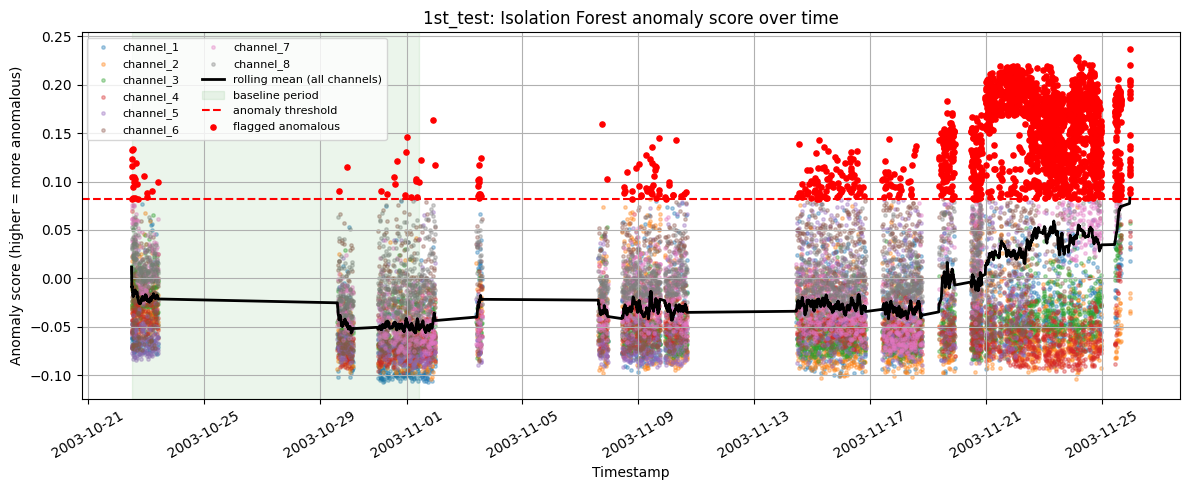

Saved plot to C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\2nd_test_anomaly_scores.png


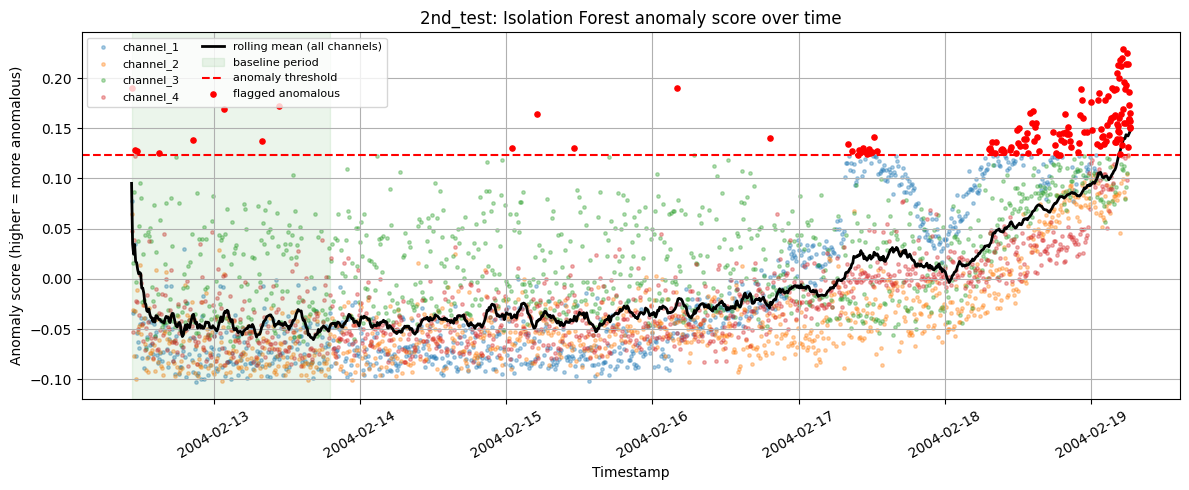

Saved plot to C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\3rd_test_anomaly_scores.png


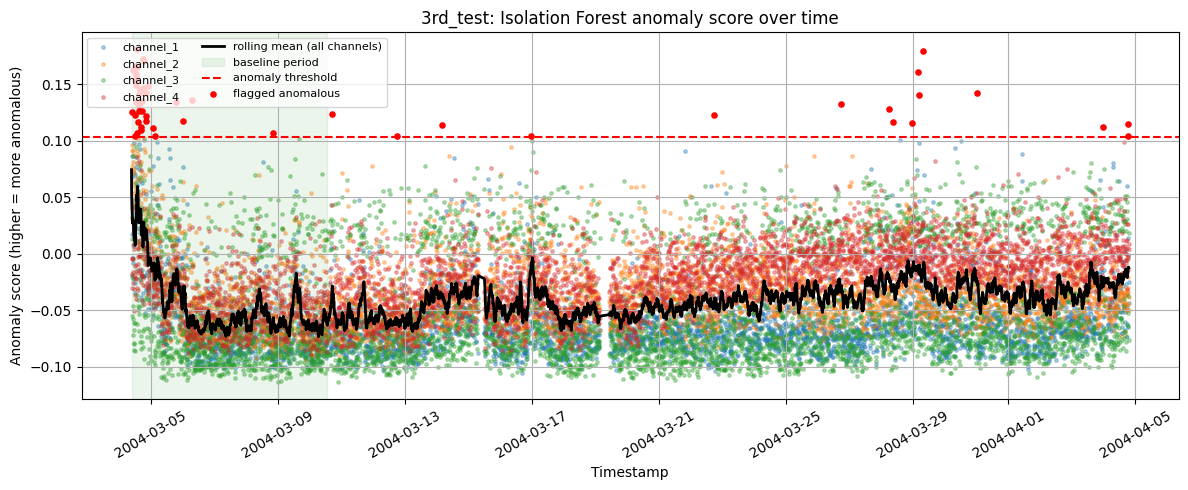

In [35]:
def plot_anomaly_scores(scored_run, run_name, threshold, baseline_end_time, trend_agg, save_path=None):
    """Plot per-channel anomaly scores over time for one run, with threshold/baseline/trend overlays."""
    fig, ax = plt.subplots(figsize=(12, 5))

    channels = sorted(scored_run["channel"].unique())
    cmap = plt.get_cmap("tab10")
    for i, ch in enumerate(channels):
        ch_data = scored_run[scored_run["channel"] == ch].sort_values("timestamp")
        ax.scatter(ch_data["timestamp"], ch_data["anomaly_score"],
                   s=6, alpha=0.35, color=cmap(i % 10), label=ch)

    ax.plot(trend_agg["timestamp"], trend_agg["rolling_mean_score"],
            color="black", linewidth=2, label="rolling mean (all channels)")

    run_start = scored_run["timestamp"].min()
    ax.axvspan(run_start, baseline_end_time, color="green", alpha=0.08, label="baseline period")
    ax.axhline(threshold, color="red", linestyle="--", linewidth=1.5, label="anomaly threshold")

    anomalous = scored_run[scored_run["anomaly_flag"]]
    ax.scatter(anomalous["timestamp"], anomalous["anomaly_score"],
               s=14, color="red", zorder=5, label="flagged anomalous")

    ax.set_xlabel("Timestamp")
    ax.set_ylabel("Anomaly score (higher = more anomalous)")
    ax.set_title(f"{run_name}: Isolation Forest anomaly score over time")
    ax.legend(loc="upper left", fontsize=8, ncol=2)
    ax.tick_params(axis="x", rotation=30)
    plt.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, dpi=150)
        print(f"Saved plot to {save_path}")

    plt.show()


for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    save_path = RESULTS_DIR / f"{run}_anomaly_scores.png"
    plot_anomaly_scores(
        run_data[run]["scored"], run, run_data[run]["threshold"],
        run_data[run]["baseline_end_time"], run_data[run]["trend_agg"],
        save_path=save_path,
    )


## 19. Model Diagnostics Summary

A compact per-run summary of everything needed to audit or reproduce the modeling step: sample counts, threshold, key hyperparameters, and timing.


In [36]:
diagnostics_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    diagnostics_rows.append({
        "run": run,
        "n_baseline_samples": len(run_data[run]["baseline_scored"]),
        "n_scored_samples": len(scored),
        "n_predicted_anomalies": int(scored["anomaly_flag"].sum()),
        "anomaly_pct": float(scored["anomaly_flag"].mean() * 100),
        "threshold": run_data[run]["threshold"],
        "n_estimators": CONFIG["N_ESTIMATORS"],
        "contamination": CONFIG["CONTAMINATION"],
        "max_samples": CONFIG["MAX_SAMPLES"],
        "max_features": CONFIG["MAX_FEATURES"],
        "training_time_s": training_times.get(run),
        "scoring_time_s": scoring_times.get(run),
    })

diagnostics_summary = pd.DataFrame(diagnostics_rows)
diagnostics_summary


,run,n_baseline_samples,n_scored_samples,n_predicted_anomalies,anomaly_pct,threshold,n_estimators,contamination,max_samples,max_features,training_time_s,scoring_time_s
0,1st_test,3448,17248,2035,11.798469,0.081905,300,auto,auto,1.0,0.484632,0.530250
1,2nd_test,784,3936,140,3.556911,0.123229,300,auto,auto,1.0,0.433093,0.140370
2,3rd_test,3556,17792,52,0.292266,0.102849,300,auto,auto,1.0,0.417392,0.576883


## 20. Save Outputs

We save, per run: the fitted model and scaler (`models/IMS/`), the full scored table (`results/IMS/isolation_forest/`), and a JSON summary of the whole run (metrics + config). Plots were already saved to disk in Section 18. Saving per-run artifacts (rather than one combined model) matches the fact that each run has its own model and its own feature space size.


In [37]:
def save_results(run, run_info, config, models_dir, results_dir):
    scores_path = results_dir / f"{run}_scores.csv"
    scores_out_cols = [
        "test_set",
        "timestamp",
        "channel",
        "anomaly_score",
        "anomaly_flag",
        "model_predict",
        "had_missing_features",
    ] + FEATURE_COLUMNS
    # Keep only columns that actually exist
    scores_out_cols = [
        col for col in scores_out_cols
        if col in run_info["scored"].columns
    ]
    run_info["scored"][scores_out_cols].to_csv(
        scores_path,
        index=False
    )
    return scores_path

saved_paths = {}
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scores_path = save_results(
        run,
        run_data[run],
        CONFIG,
        MODELS_DIR,
        RESULTS_DIR,
    )
    saved_paths[run] = {
        "scores": scores_path
    }
    print(f"{run}: saved scores -> {scores_path}")
print("\n✓ All run-specific results saved.")


1st_test: saved scores -> C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\1st_test_scores.csv
2nd_test: saved scores -> C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\2nd_test_scores.csv
3rd_test: saved scores -> C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\3rd_test_scores.csv

✓ All run-specific results saved.


In [38]:
# Combined scores across all runs, useful for Notebook 04/05 comparisons.
all_scores_cols = ["test_set", "timestamp", "channel", "anomaly_score",
                    "anomaly_flag", "model_predict", "had_missing_features"] + FEATURE_COLUMNS
all_scores_df = pd.concat(
    [run_data[run]["scored"][all_scores_cols] for run in CONFIG["RUNS"] if run in run_data],
    ignore_index=True,
)
combined_scores_path = RESULTS_DIR / "all_runs_scores.csv"
all_scores_df.to_csv(combined_scores_path, index=False)
print(f"Saved combined scores ({len(all_scores_df)} rows) -> {combined_scores_path}")


Saved combined scores (38976 rows) -> C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\all_runs_scores.csv


In [39]:
summary_json = {
    "notebook": "03_IMS_Isolation_Forest",
    "generated_at": datetime.now().isoformat(),
    "config": CONFIG,
    "feature_columns": FEATURE_COLUMNS,
    "runs": {},
}

for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    trend_row = trend_summary[trend_summary["run"] == run].iloc[0].to_dict()
    ew_row = early_warning_summary[early_warning_summary["run"] == run].iloc[0].to_dict()

    summary_json["runs"][run] = {
        "n_baseline_samples": len(run_data[run]["baseline_scored"]),
        "n_scored_samples": len(scored),
        "n_predicted_anomalies": int(scored["anomaly_flag"].sum()),
        "anomaly_pct": float(scored["anomaly_flag"].mean() * 100),
        "threshold": run_data[run]["threshold"],
        "baseline_end_time": str(run_data[run]["baseline_end_time"]),
        "training_time_s": training_times.get(run),
        "scoring_time_s": scoring_times.get(run),
        "spearman_rho": trend_row["spearman_rho"],
        "spearman_p_value": trend_row["p_value"],
        "trend_direction": trend_row["trend_direction"],
        "first_anomaly_timestamp": str(ew_row["first_anomaly_timestamp"]),
        "fraction_before_first_anomaly": ew_row["fraction_before_first_anomaly"],
        "n_near_flat_observations": int(scored["had_missing_features"].sum()),
    }

summary_path = RESULTS_DIR / "isolation_forest_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary_json, f, indent=2, default=str)

print(f"Saved summary JSON -> {summary_path}")


Saved summary JSON -> C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest\isolation_forest_summary.json


## 21. Final Verification

A final automated checklist confirming the methodological constraints from Section 1 were actually respected in this run of the notebook, not just described.


In [40]:
checks = []
trained_on_baseline_only = all(len(run_data[r]["baseline_filled"]) < len(run_data[r]["full_filled"])for r in run_data)
checks.append(("Model trained only on baseline data", trained_on_baseline_only))
no_nan_inf = all(
    (
        not run_data[r]["scored"][FEATURE_COLUMNS]
        .isnull()
        .any()
        .any()
    )
    and (
        not np.isinf(
            run_data[r]["scored"][FEATURE_COLUMNS].values
        ).any()
    )
    for r in run_data
)
checks.append(("No NaN/Inf values in scored feature columns", no_nan_inf))
feature_count_consistent = all(
    hasattr(run_data[r]["scaler"], "mean_")
    and len(run_data[r]["scaler"].mean_) == len(FEATURE_COLUMNS)
    for r in run_data
)
checks.append(("Per-run scalers have correct feature count", feature_count_consistent))
scores_complete = all(
    len(run_data[r]["scored"]) == len(run_data[r]["full_filled"])
    for r in run_data
)
checks.append(("Scores generated for all observations", scores_complete))
threshold_from_baseline = all(
    "threshold" in run_data[r] for r in run_data
)
checks.append(("Threshold derived from baseline data only", threshold_from_baseline))
all_runs_processed = set(run_data.keys()) == set(CONFIG["RUNS"])
checks.append(("All three IMS runs processed", all_runs_processed))
model_saved = all(
    run_data[r]["model_path"].exists() and run_data[r]["model"] is not None
    for r in run_data
)
checks.append(("Per-run Isolation Forest models successfully saved", model_saved))

scaler_saved = all(
    run_data[r]["scaler_path"].exists() and run_data[r]["scaler"] is not None
    for r in run_data
)
checks.append(("Per-run scalers successfully saved", scaler_saved))
scores_saved = (
    all(
        saved_paths[r]["scores"].exists()
        for r in saved_paths
    )
    and combined_scores_path.exists()
)
checks.append(("Scores successfully saved", scores_saved))
plots_saved = all(
    (
        RESULTS_DIR / f"{r}_anomaly_scores.png"
    ).exists()
    for r in run_data
)
checks.append(("Plots successfully saved", plots_saved))
print("=" * 70)
print("FINAL VERIFICATION")
print("=" * 70)
all_passed = True
for name, passed in checks:
    status = "PASS" if passed else "FAIL"
    if not passed:
        all_passed = False
    print(f"  [{status}] {name}")
print("=" * 70)
if all_passed:print("✓ ALL CHECKS PASSED")
else:print("✗ SOME CHECKS FAILED - review the items above")
print("=" * 70)

FINAL VERIFICATION
  [PASS] Model trained only on baseline data
  [PASS] No NaN/Inf values in scored feature columns
  [PASS] Per-run scalers have correct feature count
  [PASS] Scores generated for all observations
  [PASS] Threshold derived from baseline data only
  [PASS] All three IMS runs processed
  [PASS] Per-run Isolation Forest models successfully saved
  [PASS] Per-run scalers successfully saved
  [PASS] Scores successfully saved
  [PASS] Plots successfully saved
✓ ALL CHECKS PASSED


## 22. Conclusion


In [41]:
print("=" * 60)
print("NOTEBOOK 03 - ISOLATION FOREST - FINAL SUMMARY")
print("=" * 60)
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"]
    print(f"\n{run}:")
    print(f"  Baseline observations : {len(run_data[run]['baseline_scored'])}")
    print(f"  Total scored          : {len(scored)}")
    print(f"  Anomalies flagged     : {int(scored['anomaly_flag'].sum())} "
          f"({scored['anomaly_flag'].mean()*100:.2f}%)")
    print(f"  Threshold             : {run_data[run]['threshold']:.4f}")
    print(f"  Spearman rho (trend)  : "
          f"{trend_summary.loc[trend_summary['run']==run, 'spearman_rho'].values[0]:.3f}")

print(f"\nModels saved to   : {MODELS_DIR}")
print(f"Results saved to  : {RESULTS_DIR}")
print("\nNotebook 03 complete. Ready for 04_IMS_Autoencoder.ipynb.")


NOTEBOOK 03 - ISOLATION FOREST - FINAL SUMMARY

1st_test:
  Baseline observations : 3448
  Total scored          : 17248
  Anomalies flagged     : 2035 (11.80%)
  Threshold             : 0.0819
  Spearman rho (trend)  : 0.712

2nd_test:
  Baseline observations : 784
  Total scored          : 3936
  Anomalies flagged     : 140 (3.56%)
  Threshold             : 0.1232
  Spearman rho (trend)  : 0.788

3rd_test:
  Baseline observations : 3556
  Total scored          : 17792
  Anomalies flagged     : 52 (0.29%)
  Threshold             : 0.1028
  Spearman rho (trend)  : 0.323

Models saved to   : C:\chadha Summer Internship\2nd\Predictive Maintenance\models\IMS
Results saved to  : C:\chadha Summer Internship\2nd\Predictive Maintenance\results\IMS\isolation_forest

Notebook 03 complete. Ready for 04_IMS_Autoencoder.ipynb.


In [42]:
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue

    scored = run_data[run]["scored"].copy()

    scored["rolling_mean"] = (
        scored["anomaly_score"]
        .rolling(window=50, min_periods=1)
        .mean()
    )

    run_data[run]["scored"] = scored

In [43]:
for run in CONFIG["RUNS"]:
    if run in run_data:
        print(
            run,
            "rolling_mean exists:",
            "rolling_mean" in run_data[run]["scored"].columns
        )

1st_test rolling_mean exists: True
2nd_test rolling_mean exists: True
3rd_test rolling_mean exists: True


In [44]:
# ============================================================
# FINAL ISOLATION FOREST EVALUATION — CONSOLIDATED
# ============================================================
final_rows = []
for run in CONFIG["RUNS"]:
    if run not in run_data:
        continue
    scored = run_data[run]["scored"].copy()
    # Basic metrics
    total_observations = len(scored)
    anomalies_flagged = int(scored["anomaly_flag"].sum())
    anomaly_rate = 100 * anomalies_flagged / total_observations
    # Threshold: single source of truth (Section 12) - not recomputed here.
    threshold = run_data[run]["threshold"]
    # Run end
    run_end = scored["timestamp"].max()
    # Recover previously calculated persistent-warning result
    persistent_row = persistent_warning_summary[
        persistent_warning_summary["run"] == run
    ]
    if not persistent_row.empty:
        first_persistent = persistent_row.iloc[0][
            "first_persistent_anomaly_timestamp"
        ]
        # Guard consistent with Section 17/18's fix: no persistent anomaly -> None,
        # not a crash on (run_end - None).
        warning_hours = (
            (run_end - first_persistent).total_seconds() / 3600
            if pd.notna(first_persistent) else None
        )
    else:
        first_persistent = None
        warning_hours = None
    # Spearman trend: authoritative value, taken directly from Section 16's
    # trend_summary (raw per-timestamp anomaly score) - the same number reported
    # in summary_json. Not recomputed here.
    trend_row = trend_summary.loc[trend_summary["run"] == run]
    spearman_rho = float(trend_row["spearman_rho"].iloc[0]) if not trend_row.empty else None

    # Separate, exploratory-only diagnostic: Spearman on the 50-window rolling-
    # smoothed score (cell 57). Smoothing before correlating inflates apparent
    # monotonic trend strength, so this is kept clearly distinct from the
    # authoritative `spearman_rho` above and must not be read as the same metric.
    if "rolling_mean" in scored.columns:
        trend_data = scored[["timestamp", "rolling_mean"]].dropna()
        if len(trend_data) > 1:
            time_rank = (
                trend_data["timestamp"]
                .rank(method="average")
            )
            spearman_rho_rolling_smoothed_diagnostic = time_rank.corr(
                trend_data["rolling_mean"],
                method="spearman"
            )
        else:
            spearman_rho_rolling_smoothed_diagnostic = None
    else:
        spearman_rho_rolling_smoothed_diagnostic = None
    final_rows.append({
        "run": run,
        "total_observations": total_observations,
        "anomalies_flagged": anomalies_flagged,
        "anomaly_rate": round(anomaly_rate, 2),
        "threshold": round(threshold, 4),
        "spearman_rho": (
            round(spearman_rho, 3)
            if spearman_rho is not None
            else None
        ),
        "spearman_rho_rolling_smoothed_diagnostic": (
            round(spearman_rho_rolling_smoothed_diagnostic, 3)
            if spearman_rho_rolling_smoothed_diagnostic is not None
            else None
        ),
        "first_persistent_anomaly": first_persistent,
        "run_end": run_end,
        "warning_time_before_end_hours": (
            round(warning_hours, 2)
            if warning_hours is not None
            else None
        )
    })

final_evaluation = pd.DataFrame(final_rows)

print("=" * 80)
print("FINAL ISOLATION FOREST EVALUATION")
print("=" * 80)

display(final_evaluation)

FINAL ISOLATION FOREST EVALUATION


,run,total_observations,anomalies_flagged,anomaly_rate,threshold,spearman_rho,spearman_rho_rolling_smoothed_diagnostic,first_persistent_anomaly,run_end,warning_time_before_end_hours
0,1st_test,17248,2035,11.80,0.0819,0.712,0.739,2003-11-21 06:54:03,2003-11-25 23:39:56,112.76
1,2nd_test,3936,140,3.56,0.1232,0.788,0.861,2004-02-19 04:32:39,2004-02-19 06:22:39,1.83
2,3rd_test,17792,52,0.29,0.1028,0.323,0.488,NaT,2004-04-04 19:01:57,NaN
